In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from rankci import (
    rank_confidence_intervals_bootstrap,
    rank_confidence_intervals_simulation,
    rank_confidence_intervals_simulation_pairwise,
    rank_ci_stepwise,
    rank_ci_stepwise_pairwise,
    rank_ci_marginal_pairwise,
    rank_ci_stepwise_simulation,
    rank_ci_stepwise_simulation_pairwise,
    rank_ci_marginal_simulation_pairwise,
    compute_pairwise,
    select_top_forecasters,
    winsorize_panel,
)
from rankci.data.philly import (
    load_spf,
    load_rtdsm,
    compute_errors,
    compute_error_panel,
)

# Data Loading

**Forecasts**: SPF microdata (individual-level NGDP forecasts by quarter and horizon)

**Realizations**: RTDSM advance estimates (`NOUTPUTQvQd.xlsx`) — the first-published GDP figure for each quarter, avoiding contamination from later revisions.

In [2]:
df = load_spf("../../data/philly/SPFmicrodata.xlsx")
print(f"SPF NGDP: {df.shape[0]} rows × {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()

SPF NGDP: 9145 rows × 12 columns
Columns: ['YEAR', 'QUARTER', 'ID', 'INDUSTRY', 'NGDP1', 'NGDP2', 'NGDP3', 'NGDP4', 'NGDP5', 'NGDP6', 'NGDPA', 'NGDPB']


/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,YEAR,QUARTER,ID,INDUSTRY,NGDP1,NGDP2,NGDP3,NGDP4,NGDP5,NGDP6,NGDPA,NGDPB
0,1968,4,1,NaN,871.0,884.0,895.0,907.0,920.0,938.0,NaN,NaN
1,1968,4,2,NaN,871.0,891.0,910.0,929.0,958.0,973.0,NaN,NaN
2,1968,4,3,NaN,871.0,883.0,894.0,906.0,924.0,944.0,NaN,NaN
3,1968,4,4,NaN,871.0,885.0,891.0,902.0,919.0,937.0,NaN,NaN
4,1968,4,5,NaN,871.0,895.0,913.0,935.0,940.0,970.0,NaN,NaN


In [3]:
noutput = load_rtdsm("../../data/philly/NOUTPUTQvQd.xlsx")
print(f"RTDSM: {noutput.shape[0]} rows × {noutput.shape[1]} columns")
noutput.head()

RTDSM: 316 rows × 242 columns


NOUTPUT65Q4  NOUTPUT66Q1  NOUTPUT66Q2  NOUTPUT66Q3  NOUTPUT66Q4  \
YEAR QUARTER                                                                    
1947 1              223.6        223.6        223.6        223.6        223.6   
     2              227.6        227.6        227.6        227.6        227.6   
     3              231.8        231.8        231.8        231.8        231.8   
     4              242.1        242.1        242.1        242.1        242.1   
1948 1              248.0        248.0        248.0        248.0        248.0   

              NOUTPUT67Q1  NOUTPUT67Q2  NOUTPUT67Q3  NOUTPUT67Q4  NOUTPUT68Q1  \
YEAR QUARTER                                                                    
1947 1              223.6        223.6        223.6        223.6        223.6   
     2              227.6        227.6        227.6        227.6        227.6   
     3              231.8        231.8        231.8        231.8        231.8   
     4              242.1        242.1        242.1        242.1        242.1   
1948 1              248.0        248.0        248.0        248.0        248.0   

              ...  NOUTPUT23Q4  NOUTPUT24Q1  NOUTPUT24Q2  NOUTPUT24Q3  \
YEAR QUARTER  ...                                                       
1947 1        ...        243.2        243.2        243.2        243.2   
     2        ...        246.0        246.0        246.0        246.0   
     3        ...        249.6        249.6        249.6        249.6   
     4        ...        259.7        259.7        259.7        259.7   
1948 1        ...        265.7        265.7        265.7        265.7   

              NOUTPUT24Q4  NOUTPUT25Q1  NOUTPUT25Q2  NOUTPUT25Q3  NOUTPUT25Q4  \
YEAR QUARTER                                                                    
1947 1              243.2        243.2        243.2        243.2        243.2   
     2              246.0        246.0        246.0        246.0        246.0   
     3              249.6        249.6        249.6        249.6        249.6   
     4              259.7        259.7        259.7        259.7        259.7   
1948 1              265.7        265.7        265.7        265.7        265.7   

              NOUTPUT26Q1  
YEAR QUARTER               
1947 1              243.2  
     2              246.0  
     3              249.6  
     4              259.7  
1948 1              265.7  

[5 rows x 242 columns]

# Sanity Checks

In [4]:
# Verify advance estimates for a few known quarters
from rankci.data.philly import advance_vintage_col, get_advance_estimate

test_cases = [(1995, 2), (1999, 2), (2008, 4), (2020, 2)]
print(f"{'Target Quarter':<20} {'Vintage Col':<18} {'Value (bn $)'}")
print("-" * 55)
for y, q in test_cases:
    col = advance_vintage_col(y, q)
    val = get_advance_estimate(y, q, noutput)
    print(f"  {y}:Q{q:<16}  {col:<18}  {val:,.1f}")

Target Quarter       Vintage Col        Value (bn $)
-------------------------------------------------------
  1995:Q2                 NOUTPUT95Q3         7,011.8
  1999:Q2                 NOUTPUT99Q3         8,893.3
  2008:Q4                 NOUTPUT09Q1         14,264.6
  2020:Q2                 NOUTPUT20Q3         19,408.8


# Forecast Errors

In [5]:
# Compute all forecast errors (all horizons)
errors_df = compute_errors(df, noutput)

# Summary by horizon
print("Error summary by horizon:")
for h in range(1, 7):
    col = f"error_NGDP{h}"
    if col in errors_df.columns:
        print(f"  {col}: mean={errors_df[col].mean():+.1f}, "
              f"std={errors_df[col].std():.1f}, "
              f"nan%={errors_df[col].isna().mean()*100:.1f}%")

errors_df.head()

Error summary by horizon:
  error_NGDP1: mean=+0.3, std=6.1, nan%=6.1%
  error_NGDP2: mean=-15.0, std=118.9, nan%=6.5%
  error_NGDP3: mean=-20.4, std=258.5, nan%=6.9%
  error_NGDP4: mean=-25.4, std=313.2, nan%=7.5%
  error_NGDP5: mean=-30.7, std=372.2, nan%=7.9%
  error_NGDP6: mean=-32.2, std=441.6, nan%=12.7%


,YEAR,QUARTER,ID,INDUSTRY,error_NGDP1,error_NGDP2,error_NGDP3,error_NGDP4,error_NGDP5,error_NGDP6
0,1968,4,1,NaN,0.2,-3.8,-8.4,-18.1,-22.3,-15.1
1,1968,4,2,NaN,0.2,3.2,6.6,3.9,15.7,19.9
2,1968,4,3,NaN,0.2,-4.8,-9.4,-19.1,-18.3,-9.1
3,1968,4,4,NaN,0.2,-2.8,-12.4,-23.1,-23.3,-16.1
4,1968,4,5,NaN,0.2,7.2,9.6,9.9,-2.3,16.9


In [6]:
# Squared error panel for NGDP3 (one-quarter-ahead) — used for MSE ranking
# Switch to metric="absolute" for MAE ranking instead
X_wide = compute_error_panel(df, noutput, indicator="NGDP", horizon=3, metric="squared")
print(f"Panel shape: {X_wide.shape[0]} quarters × {X_wide.shape[1]} forecasters")
X_wide.head()

Panel shape: 225 quarters × 345 forecasters


ID               1      2       3       4      5       6      7       8    \
YEAR QUARTER                                                                
1968 4         70.56  43.56   88.36  153.76  92.16   70.56  70.56  237.16   
1969 1           NaN   1.21  292.41  445.21    NaN  146.41  16.81  292.41   
     2        234.09    NaN  151.29  176.89    NaN  299.29    NaN  151.29   
     3         37.21    NaN   37.21     NaN    NaN   37.21    NaN     NaN   
     4         43.56    NaN    2.56   92.16    NaN   43.56  31.36   31.36   

ID               9       10   ...  596  599  600  601  602  603  604  605  \
YEAR QUARTER                  ...                                           
1968 4        108.16   70.56  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1969 1        171.61  123.21  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
     2        334.89   39.69  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
     3           NaN    8.41  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
     4         43.56     NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

ID            606  607  
YEAR QUARTER            
1968 4        NaN  NaN  
1969 1        NaN  NaN  
     2        NaN  NaN  
     3        NaN  NaN  
     4        NaN  NaN  

[5 rows x 345 columns]

# Forecaster Selection

In [7]:
# Observation counts and mean MSE per forecaster
obs_counts = X_wide.notna().sum()
mean_mse   = X_wide.mean()

stats = pd.DataFrame({
    "obs_count": obs_counts,
    "mean_mse":  mean_mse,
    "rmse":      np.sqrt(mean_mse),
}).sort_values("obs_count", ascending=False)

print(f"Total forecasters: {len(stats)}")
print(f"Forecasters with >= 20 obs: {(stats['obs_count'] >= 20).sum()}")
print(f"Forecasters with >= 50 obs: {(stats['obs_count'] >= 50).sum()}")
stats.head(20)

Total forecasters: 345
Forecasters with >= 20 obs: 148
Forecasters with >= 50 obs: 52


,obs_count,mean_mse,rmse
ID,,,
65,122,8634.247135,92.920650
426,121,122073.450497,349.390112
433,119,157364.258540,396.691642
84,119,9874.065367,99.368332
428,117,105996.918432,325.571679
411,115,133744.990174,365.711622
421,114,106525.187449,326.381966
40,107,7483.908598,86.509587
510,103,151490.430716,389.217716


In [8]:
# Select top-N forecasters (adjust N here)
N = 5
X_panel = select_top_forecasters(X_wide, N=N, min_obs=20)
print(f"Selected {X_panel.shape[1]} forecasters, {X_panel.shape[0]} quarters")
print(f"Forecaster IDs: {X_panel.columns.tolist()}")

Selected 5 forecasters, 225 quarters
Forecaster IDs: [65, 426, 84, 433, 428]


# Rank Confidence Intervals

Using the stepwise bootstrap with pairwise NW-HAC standard errors (handles the unbalanced panel).

In [9]:
X = X_panel.values
population_ids = X_panel.columns.tolist()

out = rank_ci_stepwise_pairwise(X, alpha=0.2, B=5000, seed=42)

# Pairwise point-estimate rank (the ordering the CI procedure actually uses):
# 1 + (# k where delta_hat[j, k] > 0 on overlap), i.e. # of forecasters with
# smaller mean than j on shared quarters. On an unbalanced panel this can
# differ from the MSE (marginal-mean) sort because the marginal mean averages
# over each forecaster's full coverage while delta_hat uses only overlap.
delta_hat, _, _ = compute_pairwise(X, se_method="nw")
pair_rank = (delta_hat > 0).sum(axis=1) + 1

results = pd.DataFrame({
    "ID":         population_ids,
    "MSE":        out["theta_hat"].round(1),
    "RMSE":       np.sqrt(out["theta_hat"]).round(1),
    "pair_rank":  pair_rank,
    "CI_lower":   out["rank_ci"][:, 0],
    "CI_upper":   out["rank_ci"][:, 1],
}).sort_values("MSE")
results.index = range(1, len(results) + 1)
results.index.name = "MSE_rank"
results

=== Pairwise shared observations ===
  Min: 54, Mean: 75.3, Max: 106
  Pairs with < 20 shared obs: 0
  Block length: 3

=== Test statistics (delta_hat / se) ===
  Max: 2.8171, Pairs with t > 1.96: 2


,ID,MSE,RMSE,pair_rank,CI_lower,CI_upper
MSE_rank,,,,,,
1,65,8634.2,92.9,5,3,5
2,84,9874.1,99.4,2,1,5
3,428,105996.9,325.6,2,1,5
4,426,122073.5,349.4,2,1,4
5,433,157364.3,396.7,4,1,4


# Worst-Quarter Inspection

The CIs are uninformative — every forecaster gets rank `[1, 8]`. To understand why, look at which quarters dominate the squared-error series and whether they reflect genuine forecast misses or data artifacts.

Time coverage: (np.int64(1968), np.int64(4)) to (np.int64(2025), np.int64(1)) (225 quarters)

Top 10 quarters with highest average squared error:
YEAR  QUARTER
2020  1          7.251900e+06
      2          1.995951e+06
2023  2          7.158896e+05
      3          6.056443e+05
2020  3          5.286722e+05
2023  1          5.122452e+05
2022  3          4.218763e+05
      4          3.210769e+05
2013  2          2.937159e+05
2021  1          2.377627e+05
dtype: float64


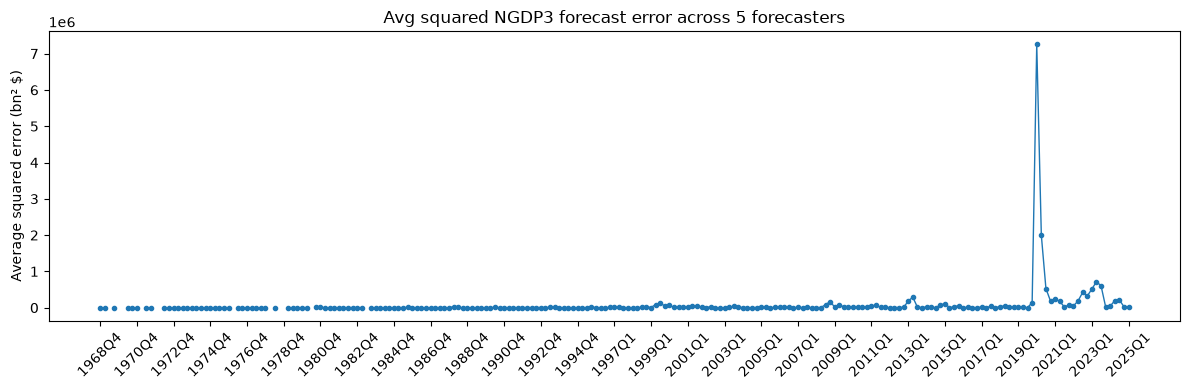

In [10]:
# Average squared error per quarter, across the selected forecasters
period_mse = X_panel.mean(axis=1)

print(f"Time coverage: {X_panel.index[0]} to {X_panel.index[-1]} ({len(X_panel)} quarters)\n")
print("Top 10 quarters with highest average squared error:")
print(period_mse.nlargest(10))

# Plot MSE over time
n = len(X_panel)
plt.figure(figsize=(12, 4))
plt.plot(range(n), period_mse, marker="o", linewidth=1, markersize=3)
plt.xticks(
    ticks=range(0, n, 8),
    labels=[f"{y}Q{q}" for y, q in X_panel.index[::8]],
    rotation=45,
)
plt.ylabel("Average squared error (bn² $)")
plt.title(f"Avg squared NGDP3 forecast error across {N} forecasters")
plt.tight_layout()
plt.show()

In [11]:
# Recover the original SPF level forecasts for the worst quarters
# to confirm the errors reflect genuine forecast misses (not data alignment bugs).
worst_quarters = period_mse.nlargest(3).index.tolist()

print("Original SPF NGDP3 forecasts vs advance estimate, worst quarters:\n")
for (y, q) in worst_quarters:
    actual = get_advance_estimate(y, q, noutput)

    # NGDP3 targeting (y, q) was submitted in survey (y, q-1)
    survey_y, survey_q = (y, q - 1) if q > 1 else (y - 1, 4)

    subset = df[
        (df["YEAR"] == survey_y) &
        (df["QUARTER"] == survey_q) &
        (df["ID"].isin(population_ids))
    ][["ID", "NGDP3"]]

    print(f"Target {y}Q{q}  (survey {survey_y}Q{survey_q})  actual = {actual:,.1f}")
    for _, row in subset.iterrows():
        err = row["NGDP3"] - actual
        print(f"    ID {int(row['ID']):>4}  forecast = {row['NGDP3']:>10,.1f}   error = {err:>+10,.1f}")
    print()

Original SPF NGDP3 forecasts vs advance estimate, worst quarters:

Target 2020Q1  (survey 2019Q4)  actual = 21,537.9
    ID  426  forecast =   21,959.5   error =     +421.6
    ID  428  forecast =   21,929.3   error =     +391.4
    ID  433  forecast =   21,845.7   error =     +307.8

Target 2020Q2  (survey 2020Q1)  actual = 19,408.8
    ID  426  forecast =   22,204.4   error =   +2,795.6
    ID  428  forecast =   22,047.2   error =   +2,638.4
    ID  433  forecast =   22,050.7   error =   +2,641.9

Target 2023Q2  (survey 2023Q1)  actual = 26,835.0
    ID  428  forecast =   26,516.7   error =     -318.3
    ID  433  forecast =   25,874.2   error =     -960.8



# Winsorization

Crisis quarters (COVID, dot-com peak) inflate the variance of the pairwise difference series, which widens the SEs and the bootstrap critical value. Two ways to limit their influence:

1. **Winsorize the squared-error panel** before computing pairwise differences (clip top tail per forecaster).
2. **Winsorize each pairwise difference series** symmetrically, just before the NW SE.

Both are exploratory — we want to see if the gap between max test statistic and bootstrap critical value closes.

In [12]:
# Variant 1: winsorize the squared-error panel per-forecaster (upper tail only)
print("=== Variant 1: winsorize the panel ===")
print(f"{'upper_pct':<12} {'max_t':<10} {'mean CI width':<16}")
print("-" * 40)
for upper_pct in [99, 97, 95, 90]:
    Xw = winsorize_panel(X, upper_pct=upper_pct)
    delta_w, se_w, _ = compute_pairwise(Xw, se_method="nw")
    t_vals = (delta_w / se_w)[~np.isnan(se_w)]

    out_w = rank_ci_stepwise_pairwise(Xw, alpha=0.05, B=1000, seed=42, verbose=False)
    widths = out_w["rank_ci"][:, 1] - out_w["rank_ci"][:, 0]

    print(f"  {upper_pct:<10} {t_vals.max():<10.3f} {widths.mean():<16.2f}")

=== Variant 1: winsorize the panel ===
upper_pct    max_t      mean CI width   
----------------------------------------


  99         2.837      3.60            
  97         1.808      4.00            
  95         1.958      4.00            
  90         2.170      4.00            


In [13]:
# Variant 2: winsorize each pairwise difference series (symmetric, in the SE itself)
print("=== Variant 2: winsorize differences ===")
print(f"{'winsor_pct':<12} {'max_t':<10} {'mean CI width':<16}")
print("-" * 40)
for winsor_pct in [99, 97, 95, 90]:
    delta_w, se_w, _ = compute_pairwise(X, se_method="nw", winsor_pct=winsor_pct)
    t_vals = (delta_w / se_w)[~np.isnan(se_w)]

    out_w = rank_ci_stepwise_pairwise(
        X, alpha=0.05, B=1000, seed=42, winsor_pct=winsor_pct, verbose=False,
    )
    widths = out_w["rank_ci"][:, 1] - out_w["rank_ci"][:, 0]

    print(f"  {winsor_pct:<10} {t_vals.max():<10.3f} {widths.mean():<16.2f}")

=== Variant 2: winsorize differences ===
winsor_pct   max_t      mean CI width   
----------------------------------------
  99         2.934      4.00            


  97         3.090      4.00            
  95         3.352      4.00            


  90         3.851      4.00            


# Marginal Rank Confidence Intervals

The simultaneous procedure controls the joint coverage probability across all forecasters at level 1−α. The **marginal** procedure controls only the per-forecaster coverage — each forecaster `j` gets its own bootstrap critical value from the `2(p−1)` test statistics involving `j`. This is statistically weaker (no family-wise control) but yields tighter intervals.

In [14]:
out_marg = rank_ci_marginal_pairwise(X, alpha=0.2, B=5000, seed=42)

# Pairwise point-estimate rank (see preceding section for definition).
delta_hat, _, _ = compute_pairwise(X, se_method="nw")
pair_rank = (delta_hat > 0).sum(axis=1) + 1

results_marg = pd.DataFrame({
    "ID":         population_ids,
    "MSE":        out_marg["theta_hat"].round(1),
    "RMSE":       np.sqrt(out_marg["theta_hat"]).round(1),
    "cv_j":       out_marg["critical_values"].round(3),
    "pair_rank":  pair_rank,
    "CI_lower":   out_marg["rank_ci"][:, 0],
    "CI_upper":   out_marg["rank_ci"][:, 1],
}).sort_values("MSE")
results_marg.index = range(1, len(results_marg) + 1)
results_marg.index.name = "MSE_rank"
results_marg

,ID,MSE,RMSE,cv_j,pair_rank,CI_lower,CI_upper
MSE_rank,,,,,,,
1,65,8634.2,92.9,1.708,5,3,5
2,84,9874.1,99.4,1.901,2,1,5
3,428,105996.9,325.6,1.933,2,1,5
4,426,122073.5,349.4,1.929,2,1,4
5,433,157364.3,396.7,1.806,4,1,4


In [15]:
# Side-by-side: simultaneous (stepwise) vs. marginal
comparison = pd.DataFrame({
    "ID":         population_ids,
    "MSE":        out["theta_hat"].round(1),
    "CI_step":    [f"[{l},{u}]" for l, u in out["rank_ci"]],
    "CI_marg":    [f"[{l},{u}]" for l, u in out_marg["rank_ci"]],
}).sort_values("MSE").reset_index(drop=True)
comparison.index += 1
comparison.index.name = "Rank"
comparison

,ID,MSE,CI_step,CI_marg
Rank,,,,
1,65,8634.2,"[3,5]","[3,5]"
2,84,9874.1,"[1,5]","[1,5]"
3,428,105996.9,"[1,5]","[1,5]"
4,426,122073.5,"[1,4]","[1,4]"
5,433,157364.3,"[1,4]","[1,4]"


# Sensitivity to NW bandwidth `L`

The Newey-West HAC standard error has a bandwidth `L` that controls how many lags of autocovariance are included. By default the package uses the automatic rule `L = floor(4 · (n/100)^{2/9})`. Larger `L` includes more autocovariance terms, which can either widen or tighten the SE depending on the autocorrelation structure of the pairwise difference series.

Here we sweep `L ∈ {None, 1, 2, 4, 8}` for the marginal procedure and tabulate the resulting CIs. `None` means use the automatic rule.

In [16]:
L_values = [None, 1, 2, 4, 8, 20]

ci_by_L = {}
maxt_by_L = {}
for L in L_values:
    delta, se, _ = compute_pairwise(X, se_method="nw", L=L)
    maxt_by_L[L] = float(np.nanmax(delta / se))
    out_L = rank_ci_marginal_pairwise(X, alpha=0.05, B=2000, seed=42, L=L)
    ci_by_L[L] = out_L["rank_ci"]

# Order forecasters by MSE (so the table reads top = best)
order = np.argsort(out_marg["theta_hat"])
ordered_ids = [population_ids[i] for i in order]

table = pd.DataFrame(
    {
        f"L={L if L is not None else 'auto (~3-4)'}":
            [f"[{ci_by_L[L][i, 0]},{ci_by_L[L][i, 1]}]" for i in order]
        for L in L_values
    },
    index=ordered_ids,
)
table.index.name = "ID"

print("max test stat by L:")
for L, t in maxt_by_L.items():
    print(f"  L={L if L is not None else 'auto (~3-4)':<5}  max_t = {t:.3f}")
print()
table

max test stat by L:
  L=auto (~3-4)  max_t = 2.817
  L=1      max_t = 2.888
  L=2      max_t = 2.817
  L=4      max_t = 2.804
  L=8      max_t = 2.772
  L=20     max_t = 3.083



,L=auto (~3-4),L=1,L=2,L=4,L=8,L=20
ID,,,,,,
65,"[3,5]","[3,5]","[3,5]","[2,5]","[2,5]","[1,5]"
84,"[1,5]","[1,5]","[1,5]","[1,5]","[1,5]","[1,5]"
428,"[1,5]","[1,5]","[1,5]","[1,5]","[1,5]","[1,5]"
426,"[1,4]","[1,4]","[1,4]","[1,5]","[1,5]","[1,5]"
433,"[1,5]","[1,4]","[1,4]","[1,5]","[1,5]","[1,5]"


In [17]:
# ## Diagnostic: Autocorrelation for Forecaster 433
# j_433 = population_ids.index(433)
# k = 0  # pick another forecaster
# mask = ~np.isnan(X[:, j_433]) & ~np.isnan(X[:, k])
# d = X[mask, j_433] - X[mask, k]
# d = d - d.mean()

# # Autocovariances at lags 0..25
# acov = [np.dot(d[t:], d[:len(d)-t]) / len(d) for t in range(26)]
# print("lag : γ_τ")
# for t, v in enumerate(acov):
#     sign = "−" if v < 0 else "+"
#     print(f"  {t:2d}  : {sign}{abs(v):,.0f}")


# MAE-based ranking

In [18]:
N      = 5
alpha  = 0.2
L      = None

# MAE
X_mae_wide  = compute_error_panel(df, noutput, indicator="NGDP", horizon=3, metric="absolute")
X_mae_panel = select_top_forecasters(X_mae_wide, N=N, min_obs=20)
X_mae       = X_mae_panel.values
ids_mae     = X_mae_panel.columns.tolist()

out_mae = rank_ci_marginal_pairwise(
    X_mae, alpha=alpha, B=5000, seed=42, L=L,
)

# MSE — same forecasters, same alpha/L, but using squared errors
X_mse_wide  = compute_error_panel(df, noutput, indicator="NGDP", horizon=3, metric="squared")
X_mse_panel = select_top_forecasters(X_mse_wide, N=N, min_obs=20)
X_mse       = X_mse_panel.values
ids_mse     = X_mse_panel.columns.tolist()

out_mse = rank_ci_marginal_pairwise(
    X_mse, alpha=alpha, B=5000, seed=42, L=L,
)

# Order by MAE (the focus of this cell)
order = np.argsort(out_mae["theta_hat"])

results_compare = pd.DataFrame({
    "ID":       [ids_mae[i] for i in order],
    "MAE":      out_mae["theta_hat"][order].round(2),
    "MSE":      out_mse["theta_hat"][order].round(1),
    "CI_MAE":   [f"[{l},{u}]" for l, u in out_mae["rank_ci"][order]],
    "CI_MSE":   [f"[{l},{u}]" for l, u in out_mse["rank_ci"][order]],
})
results_compare.index = range(1, len(results_compare) + 1)
results_compare.index.name = "MAE_rank"
results_compare

,ID,MAE,MSE,CI_MAE,CI_MSE
MAE_rank,,,,,
1,65,61.83,8634.2,"[3,5]","[3,5]"
2,84,62.19,9874.1,"[1,4]","[1,5]"
3,428,164.27,105996.9,"[2,5]","[1,5]"
4,426,171.64,122073.5,"[1,4]","[1,4]"
5,433,189.61,157364.3,"[1,4]","[1,4]"


# Simulation-stepwise vs. bootstrap-stepwise

The bootstrap stepwise procedure recomputes the critical value at each step by resampling the data. The **simulation** version replaces resampling with draws from `N(0, Σ̂)`, where `Σ̂` is the pairwise covariance of the mean estimator. Both target the same null distribution under the CLT — the simulation variant is much cheaper per draw and removes the bootstrap noise once `Σ̂` is fixed.

Same panel, same `alpha` and `B`, both with NW-HAC pairwise SEs.

In [19]:
import time

ALPHA   = 0.2
B_BOOT  = 5000
B_SIM   = 5000
SEED    = 42

# Use the same MSE panel as the earlier sections
X = X_panel.values
population_ids = X_panel.columns.tolist()

# Bootstrap stepwise (NW-HAC by default)
t0 = time.perf_counter()
out_boot = rank_ci_stepwise_pairwise(
    X, alpha=ALPHA, B=B_BOOT, seed=SEED, verbose=False,
)
t_boot = time.perf_counter() - t0

# Simulation stepwise, MDS covariance (Approach 1); NW-HAC SEs match the bootstrap
t0 = time.perf_counter()
out_sim = rank_ci_stepwise_simulation_pairwise(
    X, alpha=ALPHA, B=B_SIM, seed=SEED, covariance="mds", verbose=False,
)
t_sim = time.perf_counter() - t0

comparison = pd.DataFrame({
    "ID":         population_ids,
    "MSE":        out_boot["theta_hat"].round(1),
    "CI_boot":    [f"[{l},{u}]" for l, u in out_boot["rank_ci"]],
    "CI_sim":     [f"[{l},{u}]" for l, u in out_sim["rank_ci"]],
    "width_boot": out_boot["rank_ci"][:, 1] - out_boot["rank_ci"][:, 0],
    "width_sim":  out_sim["rank_ci"][:, 1] - out_sim["rank_ci"][:, 0],
}).sort_values("MSE").reset_index(drop=True)
comparison.index += 1
comparison.index.name = "Rank"

print(f"alpha = {ALPHA},  B_boot = {B_BOOT},  B_sim = {B_SIM}")
print(f"bootstrap stepwise:  {t_boot:.2f}s")
print(f"simulation stepwise: {t_sim:.2f}s  ({t_boot / t_sim:.1f}x speedup)" if t_sim > 0 else "")
print(f"mean CI width — bootstrap: {comparison['width_boot'].mean():.2f}, simulation: {comparison['width_sim'].mean():.2f}")
print(f"identical rank CIs: {(comparison['CI_boot'] == comparison['CI_sim']).all()}")
comparison

alpha = 0.2,  B_boot = 5000,  B_sim = 5000
bootstrap stepwise:  0.13s
simulation stepwise: 0.00s  (52.0x speedup)
mean CI width — bootstrap: 3.20, simulation: 4.00
identical rank CIs: False


,ID,MSE,CI_boot,CI_sim,width_boot,width_sim
Rank,,,,,,
1,65,8634.2,"[3,5]","[1,5]",2,4
2,84,9874.1,"[1,5]","[1,5]",4,4
3,428,105996.9,"[1,5]","[1,5]",4,4
4,426,122073.5,"[1,4]","[1,5]",3,4
5,433,157364.3,"[1,4]","[1,5]",3,4


## Approach 2 — direct difference covariance (Ω)

The MDS route (Approach 1) reconstructs a *level* covariance from the pairwise SEs and, on this heavy-tailed, unbalanced panel, loses calibration — its simulated critical value is inflated and every rank CI collapses to the trivial `[1, p]`. Approach 2 estimates the covariance of the pairwise **differences** directly (`covariance="omega"`, the estimator of `omega_unbalanced.tex`) and hands it to the *same* Romano–Wolf stepdown. Below it is compared against the bootstrap and the MDS simulation on the identical NGDP top-5 panel. `frob_gap` reports how much unbalancedness forced the nearest-PSD projection.

In [20]:
# Approach 2: direct difference covariance (Omega) on the same panel/settings.
from rankci import cov_via_omega

out_omega = rank_ci_stepwise_simulation_pairwise(
    X, alpha=ALPHA, B=B_SIM, seed=SEED, covariance="omega", verbose=False,
)

# Diagnostic: how far was the raw Omega from PSD before projection?
_, omega_diag = cov_via_omega(X, return_diagnostics=True)
rel_gap = omega_diag["frob_gap"] / np.linalg.norm(omega_diag["Omega_raw"], "fro")
ov = omega_diag["n_overlap"][np.triu_indices_from(omega_diag["n_overlap"], k=1)]
print(f"Omega: q={out_omega['cov'].shape[0]}, pair-of-pairs overlap n_ab in [{ov.min()},{ov.max()}]")
print(f"       min raw eigenvalue = {omega_diag['min_eig_raw']:.2e}, "
      f"relative Frobenius projection gap = {rel_gap:.2%}")

three_way = pd.DataFrame({
    "ID":       population_ids,
    "MSE":      out_boot["theta_hat"].round(1),
    "CI_boot":  [f"[{l},{u}]" for l, u in out_boot["rank_ci"]],
    "CI_mds":   [f"[{l},{u}]" for l, u in out_sim["rank_ci"]],
    "CI_omega": [f"[{l},{u}]" for l, u in out_omega["rank_ci"]],
}).sort_values("MSE").reset_index(drop=True)
three_way.index += 1
three_way.index.name = "Rank"
print(f"\nNGDP top-5, horizon 3, alpha={ALPHA}, B={B_SIM}, seed={SEED}")
three_way

Omega: q=10, pair-of-pairs overlap n_ab in [47,91]
       min raw eigenvalue = -5.26e+07, relative Frobenius projection gap = 2.65%

NGDP top-5, horizon 3, alpha=0.2, B=5000, seed=42


,ID,MSE,CI_boot,CI_mds,CI_omega
Rank,,,,,
1,65,8634.2,"[3,5]","[1,5]","[3,5]"
2,84,9874.1,"[1,5]","[1,5]","[1,5]"
3,428,105996.9,"[1,5]","[1,5]","[1,5]"
4,426,122073.5,"[1,4]","[1,5]","[1,4]"
5,433,157364.3,"[1,4]","[1,5]","[1,4]"


# Horizon sweep: bootstrap vs simulation

Run the stepwise CI procedure at every SPF horizon `h ∈ {2..6}` (nowcast through four quarters ahead) with both:

- **bootstrap** — `rank_ci_stepwise_pairwise` (resamples rows, NW-HAC SE inside the loop)
- **simulation** — `rank_ci_stepwise_simulation_pairwise` with `use_hac=True` (draws from `N(0, Σ̂)` with pairwise PSD-projected `Σ̂`)

Both use the same panel, same `α` and `B`. We report mean rank-CI width (in rank units), max t-statistic, and runtime per horizon.

In [21]:
import time

H_SWEEP   = [2, 3, 4, 5, 6]
ALPHA_HS  = 0.2
B_BOOT    = 5000
B_SIM     = 5000
N_TOP     = 5
SEED_HS   = 42

rows = []
ci_detail = {}

for h in H_SWEEP:
    Xh_wide  = compute_error_panel(df, noutput, indicator="NGDP", horizon=h, metric="squared")
    Xh_panel = select_top_forecasters(Xh_wide, N=N_TOP, min_obs=20)
    Xh       = Xh_panel.values
    ids_h    = Xh_panel.columns.tolist()

    delta_h, se_h, _ = compute_pairwise(Xh, se_method="nw")
    with np.errstate(invalid="ignore"):
        max_t = float(np.nanmax(np.abs(delta_h / se_h)))

    t0 = time.perf_counter()
    out_b = rank_ci_stepwise_pairwise(Xh, alpha=ALPHA_HS, B=B_BOOT, seed=SEED_HS, verbose=False)
    t_b = time.perf_counter() - t0

    t0 = time.perf_counter()
    out_s = rank_ci_stepwise_simulation_pairwise(
        Xh, alpha=ALPHA_HS, B=B_SIM, seed=SEED_HS, covariance="mds", verbose=False,
    )
    t_s = time.perf_counter() - t0

    width_b = (out_b["rank_ci"][:, 1] - out_b["rank_ci"][:, 0]).mean()
    width_s = (out_s["rank_ci"][:, 1] - out_s["rank_ci"][:, 0]).mean()
    p = Xh.shape[1]
    n_pairs_total = p * (p - 1)
    n_conf_b = (out_b["rank_ci"][:, 0] > 1).sum() + (out_b["rank_ci"][:, 1] < p).sum()
    n_conf_s = (out_s["rank_ci"][:, 0] > 1).sum() + (out_s["rank_ci"][:, 1] < p).sum()

    rows.append({
        "h":          h,
        "n_quarters": Xh_panel.shape[0],
        "max_t":      round(max_t, 3),
        "width_boot": round(width_b, 2),
        "width_sim":  round(width_s, 2),
        "informative_boot":  int(n_conf_b),
        "informative_sim":   int(n_conf_s),
        "t_boot_s":   round(t_b, 2),
        "t_sim_s":    round(t_s, 2),
    })
    ci_detail[h] = (ids_h, out_b["rank_ci"], out_s["rank_ci"], out_b["theta_hat"])

summary = pd.DataFrame(rows).set_index("h")
summary.index.name = "horizon"
summary

,n_quarters,max_t,width_boot,width_sim,informative_boot,informative_sim,t_boot_s,t_sim_s
horizon,,,,,,,,
2,226,2.088,4.0,4.0,0,0,0.13,0.0
3,225,2.817,3.2,4.0,3,0,0.12,0.0
4,224,2.510,3.6,4.0,2,0,0.13,0.0
5,223,2.645,3.6,4.0,2,0,0.13,0.0
6,217,2.633,3.6,4.0,2,0,0.12,0.0


In [22]:
# Per-horizon CI table (bootstrap vs simulation, side by side)
rows = []
for h in H_SWEEP:
    ids_h, rci_b, rci_s, theta_h = ci_detail[h]
    order = np.argsort(theta_h)
    for rank_i, idx in enumerate(order, start=1):
        rows.append({
            "h":        h,
            "MSE_rank": rank_i,
            "ID":       ids_h[idx],
            "MSE":      round(float(theta_h[idx]), 1),
            "CI_boot":  f"[{rci_b[idx, 0]},{rci_b[idx, 1]}]",
            "CI_sim":   f"[{rci_s[idx, 0]},{rci_s[idx, 1]}]",
        })
detail = pd.DataFrame(rows).set_index(["h", "MSE_rank"])
detail

ID       MSE CI_boot CI_sim
h MSE_rank                              
2 1          65    2643.6   [1,5]  [1,5]
  2          84    2800.7   [1,5]  [1,5]
  3         428   16367.6   [1,5]  [1,5]
  4         433   26177.3   [1,5]  [1,5]
  5         426   27028.7   [1,5]  [1,5]
3 1          65    8634.2   [3,5]  [1,5]
  2          84    9874.1   [1,5]  [1,5]
  3         428  105996.9   [1,5]  [1,5]
  4         426  122073.5   [1,4]  [1,5]
  5         433  157364.3   [1,4]  [1,5]
4 1          65   15956.6   [2,5]  [1,5]
  2          84   22555.1   [1,5]  [1,5]
  3         428  156862.5   [1,5]  [1,5]
  4         426  174893.7   [1,4]  [1,5]
  5         433  210744.6   [1,5]  [1,5]
5 1          65   27825.3   [2,5]  [1,5]
  2          84   38660.7   [1,5]  [1,5]
  3         428  225177.1   [1,5]  [1,5]
  4         426  261051.6   [1,4]  [1,5]
  5         433  273702.6   [1,5]  [1,5]
6 1          65   43549.7   [2,5]  [1,5]
  2         421  289883.5   [1,5]  [1,5]
  3         428  298220.3   [1,5]  [1,5]
  4         426  348214.6   [1,4]  [1,5]
  5         433  348650.4   [1,5]  [1,5]

# Stable-period analysis

The full-sample CIs are dominated by crisis quarters (COVID, 2008 GFC, 1991, 1985 rebasing). To check whether the top-5 forecasters separate when the heavy tails are excluded, restrict to a "calm" window: **1992:Q1 – 2007:Q4** — between the 1991 recession and the 2008 financial crisis, containing only the mild 2001 slowdown.

This keeps the same top-5 forecasters identified on the full sample (so the comparison is window-vs-full on a fixed forecaster set) and re-runs the stepwise (bootstrap + simulation) and marginal procedures at the chosen `α`.

Stable window: (np.int64(1992), np.int64(1)) → (np.int64(2007), np.int64(4)) (63 quarters)
Full panel: 225 quarters (excluded 162)


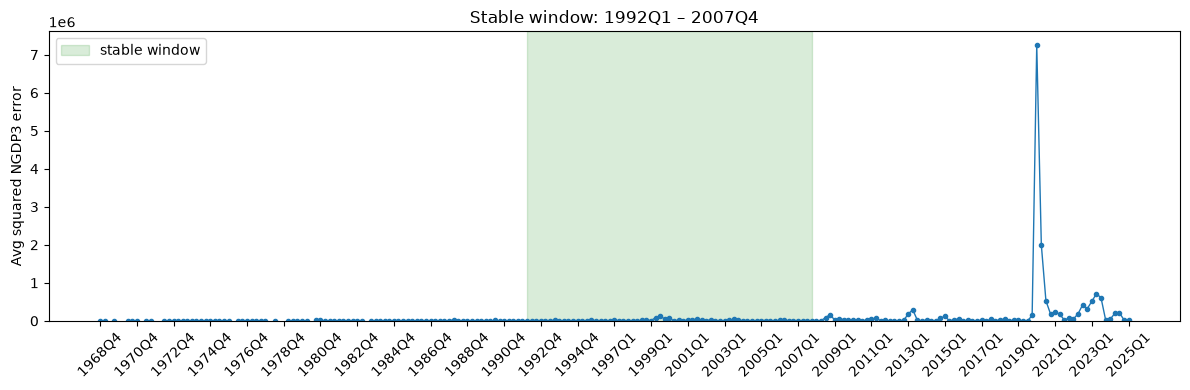

In [23]:
STABLE_START = (1992, 1)
STABLE_END   = (2007, 4)

in_win = np.array([STABLE_START <= idx <= STABLE_END for idx in X_panel.index])
X_stable = X_panel[in_win]

print(f"Stable window: {X_stable.index[0]} → {X_stable.index[-1]} ({len(X_stable)} quarters)")
print(f"Full panel: {len(X_panel)} quarters (excluded {len(X_panel) - len(X_stable)})")

# Plot the avg squared-error series, highlighting the stable window
period_mse = X_panel.mean(axis=1)
fig, ax = plt.subplots(figsize=(12, 4))
xs = np.arange(len(X_panel))
ax.plot(xs, period_mse, marker="o", linewidth=1, markersize=3, color="C0")
ymax = period_mse.max() * 1.05
ax.fill_between(xs, 0, ymax, where=in_win, alpha=0.15, color="green", label="stable window")
ax.set_xticks(range(0, len(X_panel), 8))
ax.set_xticklabels([f"{y}Q{q}" for y, q in X_panel.index[::8]], rotation=45)
ax.set_ylabel("Avg squared NGDP3 error")
ax.set_title(f"Stable window: {STABLE_START[0]}Q{STABLE_START[1]} – {STABLE_END[0]}Q{STABLE_END[1]}")
ax.legend(loc="upper left")
ax.set_ylim(0, ymax)
plt.tight_layout()
plt.show()

In [24]:
ALPHA_W = 0.2
B_W     = 5000
SEED_W  = 42

X_st = X_stable.values

out_boot_st = rank_ci_stepwise_pairwise(
    X_st, alpha=ALPHA_W, B=B_W, seed=SEED_W, verbose=False,
)
out_sim_st = rank_ci_stepwise_simulation_pairwise(
    X_st, alpha=ALPHA_W, B=B_W, seed=SEED_W, covariance="mds", verbose=False,
)
out_marg_st = rank_ci_marginal_pairwise(
    X_st, alpha=ALPHA_W, B=B_W, seed=SEED_W,
)

# Also rerun bootstrap stepwise on the full panel at the same alpha for side-by-side
out_boot_full = rank_ci_stepwise_pairwise(
    X_panel.values, alpha=ALPHA_W, B=B_W, seed=SEED_W, verbose=False,
)

delta_st, se_st, _ = compute_pairwise(X_st, se_method="nw")
with np.errstate(invalid="ignore"):
    max_t_st = float(np.nanmax(np.abs(delta_st / se_st)))

print(f"alpha = {ALPHA_W}, B = {B_W}, window = {len(X_stable)} quarters")
print(f"Max |t| (stable window): {max_t_st:.3f}")
print()

comparison = pd.DataFrame({
    "ID":             population_ids,
    "MSE_full":       out_boot_full["theta_hat"].round(1),
    "MSE_stable":     out_boot_st["theta_hat"].round(1),
    "CI_boot_full":   [f"[{l},{u}]" for l, u in out_boot_full["rank_ci"]],
    "CI_boot_stable": [f"[{l},{u}]" for l, u in out_boot_st["rank_ci"]],
    "CI_sim_stable":  [f"[{l},{u}]" for l, u in out_sim_st["rank_ci"]],
    "CI_marg_stable": [f"[{l},{u}]" for l, u in out_marg_st["rank_ci"]],
}).sort_values("MSE_stable").reset_index(drop=True)
comparison.index += 1
comparison.index.name = "Rank (stable MSE)"
comparison

alpha = 0.2, B = 5000, window = 63 quarters
Max |t| (stable window): 2.911



,ID,MSE_full,MSE_stable,CI_boot_full,CI_boot_stable,CI_sim_stable,CI_marg_stable
Rank (stable MSE),,,,,,,
1,433,157364.3,9366.5,"[1,4]","[1,4]","[1,4]","[1,4]"
2,426,122073.5,10903.8,"[1,4]","[1,4]","[1,4]","[1,4]"
3,84,9874.1,11455.3,"[1,5]","[1,5]","[1,5]","[1,4]"
4,428,105996.9,13090.8,"[1,5]","[1,5]","[1,5]","[1,5]"
5,65,8634.2,16856.3,"[3,5]","[3,5]","[3,5]","[4,5]"


# Complete-cases simulation analysis (MAE)

The simulation procedure is most natural when the panel is balanced — `Σ̂ = cov(X) / n` is then directly the sampling covariance of `θ̂`, no pairwise/MDS construction needed. To run this regime here, restrict to the **complete cases** of the top-5 panel under absolute-error loss: drop every quarter in which any of the five forecasters is missing.

Using MAE rather than MSE has two effects:

1. **Lighter tails** — absolute errors do not square crisis-quarter misses, so the pair-difference variance is much better-behaved and the SE matrix is closer to Euclidean.
2. **Same forecaster set** — `select_top_forecasters` filters by observation count, not by loss value, and the NaN pattern is identical for `(forecast − actual)²` and `|forecast − actual|`. So the same five IDs come through.

On this complete subpanel:
- `MSE_rank` (sorted marginal mean of `|error|`) and `pair_rank` (overlap count) coincide — no overlap ambiguity left.
- Wald simulation (`rank_confidence_intervals_simulation`), stepwise simulation (`rank_ci_stepwise_simulation`), and bootstrap stepwise (`rank_ci_stepwise_pairwise`) all apply cleanly.

In [25]:
N_CC = 5

X_wide_mae  = compute_error_panel(df, noutput, indicator="NGDP", horizon=3, metric="absolute")
X_panel_mae = select_top_forecasters(X_wide_mae, N=N_CC, min_obs=20)
X_cc_mae    = X_panel_mae.dropna(how="any")
n_cc, p_cc  = X_cc_mae.shape

print(f"MAE complete-cases subpanel: {n_cc} quarters × {p_cc} forecasters")
print(f"  Dropped {len(X_panel_mae) - n_cc} of {len(X_panel_mae)} quarters with at least one missing forecaster")
print(f"  Forecaster IDs: {X_cc_mae.columns.tolist()}")
print(f"  Coverage span: {X_cc_mae.index[0]} → {X_cc_mae.index[-1]}")

MAE complete-cases subpanel: 45 quarters × 5 forecasters
  Dropped 180 of 225 quarters with at least one missing forecaster
  Forecaster IDs: [65, 426, 84, 433, 428]
  Coverage span: (np.int64(1991), np.int64(1)) → (np.int64(2007), np.int64(3))


In [26]:
ALPHA_CC = 0.2
B_CC     = 5000
SEED_CC  = 42

X_cc_arr = X_cc_mae.values
ids_cc   = X_cc_mae.columns.tolist()

# Simulation, Wald-style simultaneous CI (single critical value, no stepdown)
t0 = time.perf_counter()
out_sim_wald = rank_confidence_intervals_simulation(
    X_cc_arr, alpha=ALPHA_CC, B=B_CC, seed=SEED_CC,
)
t_sim_wald = time.perf_counter() - t0

# Simulation, stepwise refinement
t0 = time.perf_counter()
out_sim_step = rank_ci_stepwise_simulation(
    X_cc_arr, alpha=ALPHA_CC, B=B_CC, seed=SEED_CC,
)
t_sim_step = time.perf_counter() - t0

# Bootstrap stepwise on the same complete subset, for reference
t0 = time.perf_counter()
out_boot = rank_ci_stepwise_pairwise(
    X_cc_arr, alpha=ALPHA_CC, B=B_CC, seed=SEED_CC, verbose=False,
)
t_boot = time.perf_counter() - t0

# Pair rank on the complete subset (coincides with MAE rank now)
theta_cc = X_cc_arr.mean(axis=0)
delta_cc = theta_cc[:, None] - theta_cc[None, :]
pair_rank_cc = (delta_cc > 0).sum(axis=1) + 1

results_cc = pd.DataFrame({
    "ID":           ids_cc,
    "MAE":          theta_cc.round(2),
    "pair_rank":    pair_rank_cc,
    "CI_sim_wald":  [f"[{l},{u}]" for l, u in out_sim_wald["rank_ci"]],
    "CI_sim_step":  [f"[{l},{u}]" for l, u in out_sim_step["rank_ci"]],
    "CI_boot_step": [f"[{l},{u}]" for l, u in out_boot["rank_ci"]],
}).sort_values("MAE").reset_index(drop=True)
results_cc.index += 1
results_cc.index.name = "MAE_rank"

print(f"alpha = {ALPHA_CC}, B = {B_CC}, complete-cases n = {n_cc}")
print(f"timings: sim_wald={t_sim_wald:.3f}s, sim_step={t_sim_step:.3f}s, boot_step={t_boot:.3f}s")
print(f"sim_wald critical value: {out_sim_wald['critical_value']:.3f}")
print()
results_cc

alpha = 0.2, B = 5000, complete-cases n = 45
timings: sim_wald=0.024s, sim_step=0.055s, boot_step=0.092s
sim_wald critical value: 2.097



,ID,MAE,pair_rank,CI_sim_wald,CI_sim_step,CI_boot_step
MAE_rank,,,,,,
1,84,65.52,1,"[1,4]","[1,4]","[1,3]"
2,433,72.15,2,"[1,4]","[1,4]","[1,4]"
3,426,74.50,3,"[1,5]","[1,5]","[1,5]"
4,428,77.15,4,"[1,5]","[1,5]","[2,5]"
5,65,87.28,5,"[3,5]","[3,5]","[3,5]"


# τ-best confidence set (Algorithm 3.3)

Rather than reporting an interval $[L_j, U_j]$ for each forecaster's rank, the τ-best procedure of Mogstad et al. (2024, §3.4) directly constructs a set $J^{\tau\text{-best}}_n$ that contains **all** truly top-τ populations with probability $\ge 1-\alpha$. A forecaster is *excluded* from the set if there is statistical evidence that — even after exempting any $\tau-1$ other forecasters — at least one population outside the exemption is substantially better.

Two procedures are compared:

- **Naive projection** (eq. 27): include $j$ iff $L_j \le \tau$, i.e. its joint stepwise rank CI $[L_j, U_j]$ reaches rank $\tau$ or better. Eq. 27 as printed asks for $\tau \in [L_j, U_j]$, which wrongly drops forecasters with $U_j < \tau$ (certainly top-τ). Conservative; uses the existing rank-CI output directly.
- **Algorithm 3.3** (direct): test statistic $T_{n,j} = \min_K \max_{k \notin K} (\hat\theta_j - \hat\theta_k) / \widehat{\mathrm{se}}_{jk}$ over $|K| = \tau - 1$ exemption sets; bootstrap critical value $\hat c = \max_K Q_{1-\alpha}(T^*_{b,I,K})$; stepdown by removing rejected populations.

We use $\alpha = 0.2$ (matching the rest of the notebook) and sweep $\tau \in \{1, 2, 3\}$ to show how the set grows as we ask for the top-$\tau$ rather than just the single best.

In [27]:
from rankci import tau_best_pairwise, tau_best_from_rank_ci

ALPHA_TAU = 0.2
B_TAU     = 5000
SEED_TAU  = 42

# Joint stepwise rank CIs at the same alpha (basis for the naive projection)
out_rank = rank_ci_stepwise_pairwise(
    X, alpha=ALPHA_TAU, B=B_TAU, seed=SEED_TAU, verbose=False,
)

# Sweep tau ∈ {1, 2, 3}: report the two τ-best sets side by side
rows = []
for tau in [1, 2, 3]:
    res = tau_best_pairwise(
        X, tau=tau, alpha=ALPHA_TAU, B=B_TAU, seed=SEED_TAU, verbose=False,
    )
    naive = tau_best_from_rank_ci(out_rank["rank_ci"], tau=tau)
    rows.append({
        "tau":             tau,
        "n_direct":        int(res["n_in_set"]),
        "set_direct":      [population_ids[j] for j, v in enumerate(res["tau_best_set"]) if v],
        "n_naive":         int(naive.sum()),
        "set_naive":       [population_ids[j] for j, v in enumerate(naive) if v],
        "max_test_stat":   round(float(np.nanmax(res["test_stats"])), 3),
    })

tau_sweep = pd.DataFrame(rows).set_index("tau")
print(f"alpha = {ALPHA_TAU}, B = {B_TAU}, p = {len(population_ids)}")
print(f"Forecaster IDs: {population_ids}")
print()
tau_sweep

alpha = 0.2, B = 5000, p = 5
Forecaster IDs: [65, 426, 84, 433, 428]



,n_direct,set_direct,n_naive,set_naive,max_test_stat
tau,,,,,
1,4,"[426, 84, 433, 428]",4,"[426, 84, 433, 428]",2.817
2,4,"[426, 84, 433, 428]",4,"[426, 84, 433, 428]",2.526
3,5,"[65, 426, 84, 433, 428]",5,"[65, 426, 84, 433, 428]",1.598
